# `phd_ui` figure-size comparison

A **schematic** look at how each `figsize.json` preset fills the media I care about.
There are two families:

* **document** presets (9 or 18 cm wide) for papers / the thesis, and
* **presentation** presets (`slide_*`) sized to sit on a slide with room for a
  title and margins. Both 16:9 and 4:3 slides are **19.05 cm tall** — only the
  width differs (33.87 vs 25.4 cm), so the slide presets mostly differ in width.

The boxes are the real preset sizes in cm, drawn to scale. No real plots — just
sized rectangles. Outputs are dumped to the shared figure folder under `phd_ui/`:
reference PNG/PDF/SVG comparisons, a multi-page **PDF** report, and two **PPTX**
decks (16:9 and 4:3).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from pathlib import Path

import phd_ui
from phd_ui.plotting import get_figsizes, save_figure, cm_to_inches
from phd_ui.colors import create_saturation_palette

phd_ui.initialize()

# Shared dump used by the other models.
DUMP = Path(r"C:\Users\jsommer1\OneDrive\02_Projects\[UniZeug]\2024_PhD\01_Project\[figure_dump]") / "phd_ui"
DUMP.mkdir(parents=True, exist_ok=True)
print("Dumping to:", DUMP)

# Repo-local copy of the mock deliverables (docs/ next to src/).
REPO = Path.cwd().resolve()
for _p in [REPO, *REPO.parents]:
    if (_p / "pyproject.toml").exists():
        REPO = _p
        break
DOCS = REPO / "docs"
DOCS.mkdir(parents=True, exist_ok=True)
print("Docs copy:", DOCS)

In C:\Users\jsommer1\.matplotlib\stylelib\scpy.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In C:\Users\jsommer1\.matplotlib\stylelib\scpy.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


Dumping to: C:\Users\jsommer1\OneDrive\02_Projects\[UniZeug]\2024_PhD\01_Project\[figure_dump]\phd_ui
Docs copy: C:\Users\jsommer1\CODE\PhD_ui\docs


## Setup: presets, media and colours

Presets are grouped into the single / double document families and the slide
family. Colours come from `phd_ui`'s own `create_saturation_palette`: blue tints
for single, orange for double, green for the slide presets.

In [2]:
FIGSIZES_CM = get_figsizes(in_metric=True)     # name -> (w, h) in cm

# --- document families (by width), ordered by height ---
SINGLE = ["single_short", "single", "single_square", "single_double",
          "single_double_square", "single_long"]                                #  9 cm
DOUBLE = ["double_short", "double_single", "double_single_square", "double",
          "double_square", "double_long"]                                       # 18 cm
DOC = SINGLE + DOUBLE

# --- presentation family (sized for slides) ---
SLIDE_PRESETS = ["slide_half", "slide_tall", "slide_4x3", "slide_16x9"]

# --- colours ---
single_cols = create_saturation_palette("#2F6DB5", n_colors=len(SINGLE), sat_range=(0.55, 1.0))
double_cols = create_saturation_palette("#E07B39", n_colors=len(DOUBLE), sat_range=(0.40, 1.0))
slide_cols  = create_saturation_palette("#2E8B57", n_colors=len(SLIDE_PRESETS), sat_range=(0.45, 1.0))
COLOR = {}
COLOR.update({n: c for n, c in zip(SINGLE, single_cols)})
COLOR.update({n: c for n, c in zip(DOUBLE, double_cols)})
COLOR.update({n: c for n, c in zip(SLIDE_PRESETS, slide_cols)})

BAND_SINGLE, BAND_DOUBLE, BAND_SLIDE = "#2F6DB5", "#E07B39", "#2E8B57"

# --- media, in cm ---
A4        = (21.0, 29.7)      # A4 portrait
A4_MARGIN = 1.5              # -> 18 cm text width
SLIDE_169 = (33.867, 19.05)  # 16:9 PowerPoint (13.333 x 7.5 in)
SLIDE_43  = (25.4, 19.05)    # 4:3 PowerPoint  (10 x 7.5 in)

for group, label in [(DOC, "document"), (SLIDE_PRESETS, "slide")]:
    print(f"# {label}")
    for n in group:
        w, h = FIGSIZES_CM[n]
        print(f"  {n:22s} {w:5.1f} x {h:5.1f} cm")

# document
  single_short             9.0 x   4.5 cm
  single                   9.0 x   6.5 cm
  single_square            9.0 x   9.0 cm
  single_double            9.0 x  11.5 cm
  single_double_square     9.0 x  18.0 cm
  single_long              9.0 x  24.0 cm
  double_short            18.0 x   4.5 cm
  double_single           18.0 x   6.5 cm
  double_single_square    18.0 x   9.0 cm
  double                  18.0 x  11.5 cm
  double_square           18.0 x  18.0 cm
  double_long             18.0 x  24.0 cm
# slide
  slide_half              14.5 x  12.0 cm
  slide_tall              12.0 x  15.0 cm
  slide_4x3               21.0 x  14.0 cm
  slide_16x9              26.0 x  14.0 cm


## The drawing helper

`draw_medium` paints the medium, optional family bands (a light rectangle covering
each group's largest footprint), and the nested preset outlines.

In [3]:
def draw_medium(ax, page, anchor, presets, *, text_area=None, band_groups=None, title=""):
    # page/slide with `presets` overlaid from `anchor` (top-left content corner).
    #   band_groups : list of (list_of_presets, colour) light footprint bands
    pw, ph = page
    x0, ytop = anchor

    ax.add_patch(Rectangle((0, 0), pw, ph, facecolor="#F5F5F5",
                           edgecolor="#9E9E9E", lw=1.0, zorder=0))
    if text_area is not None:
        tx, ty, tw, th = text_area
        ax.add_patch(Rectangle((tx, ty), tw, th, facecolor="none",
                               edgecolor="#BDBDBD", lw=0.8, ls=(0, (4, 3)), zorder=1))

    for names, col in (band_groups or []):
        bw = max(FIGSIZES_CM[n][0] for n in names)
        bh = max(FIGSIZES_CM[n][1] for n in names)
        ax.add_patch(Rectangle((x0, ytop - bh), bw, bh, facecolor=col,
                               edgecolor="none", alpha=0.08, zorder=1.5))

    for n in sorted(presets, key=lambda k: -FIGSIZES_CM[k][0] * FIGSIZES_CM[k][1]):
        w, h = FIGSIZES_CM[n]
        ax.add_patch(Rectangle((x0, ytop - h), w, h, facecolor="none",
                               edgecolor=COLOR[n], lw=1.8, zorder=3))

    ax.set_xlim(-1.0, pw + 1.0)
    ymin = min(0.0, ytop - max(FIGSIZES_CM[n][1] for n in presets)) - 1.0
    ax.set_ylim(ymin, ph + 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=9)


def legend_handles(presets):
    out = []
    for n in presets:
        w, h = FIGSIZES_CM[n]
        out.append(Patch(facecolor="none", edgecolor=COLOR[n], lw=1.8,
                         label=f"{n}  ({w:g} x {h:g} cm)"))
    return out

## Document presets on an A4 page

18 cm text block. `single` is a half-column figure; `double` fills the width;
`double_long` (was `fullpage`) takes essentially the whole text height.

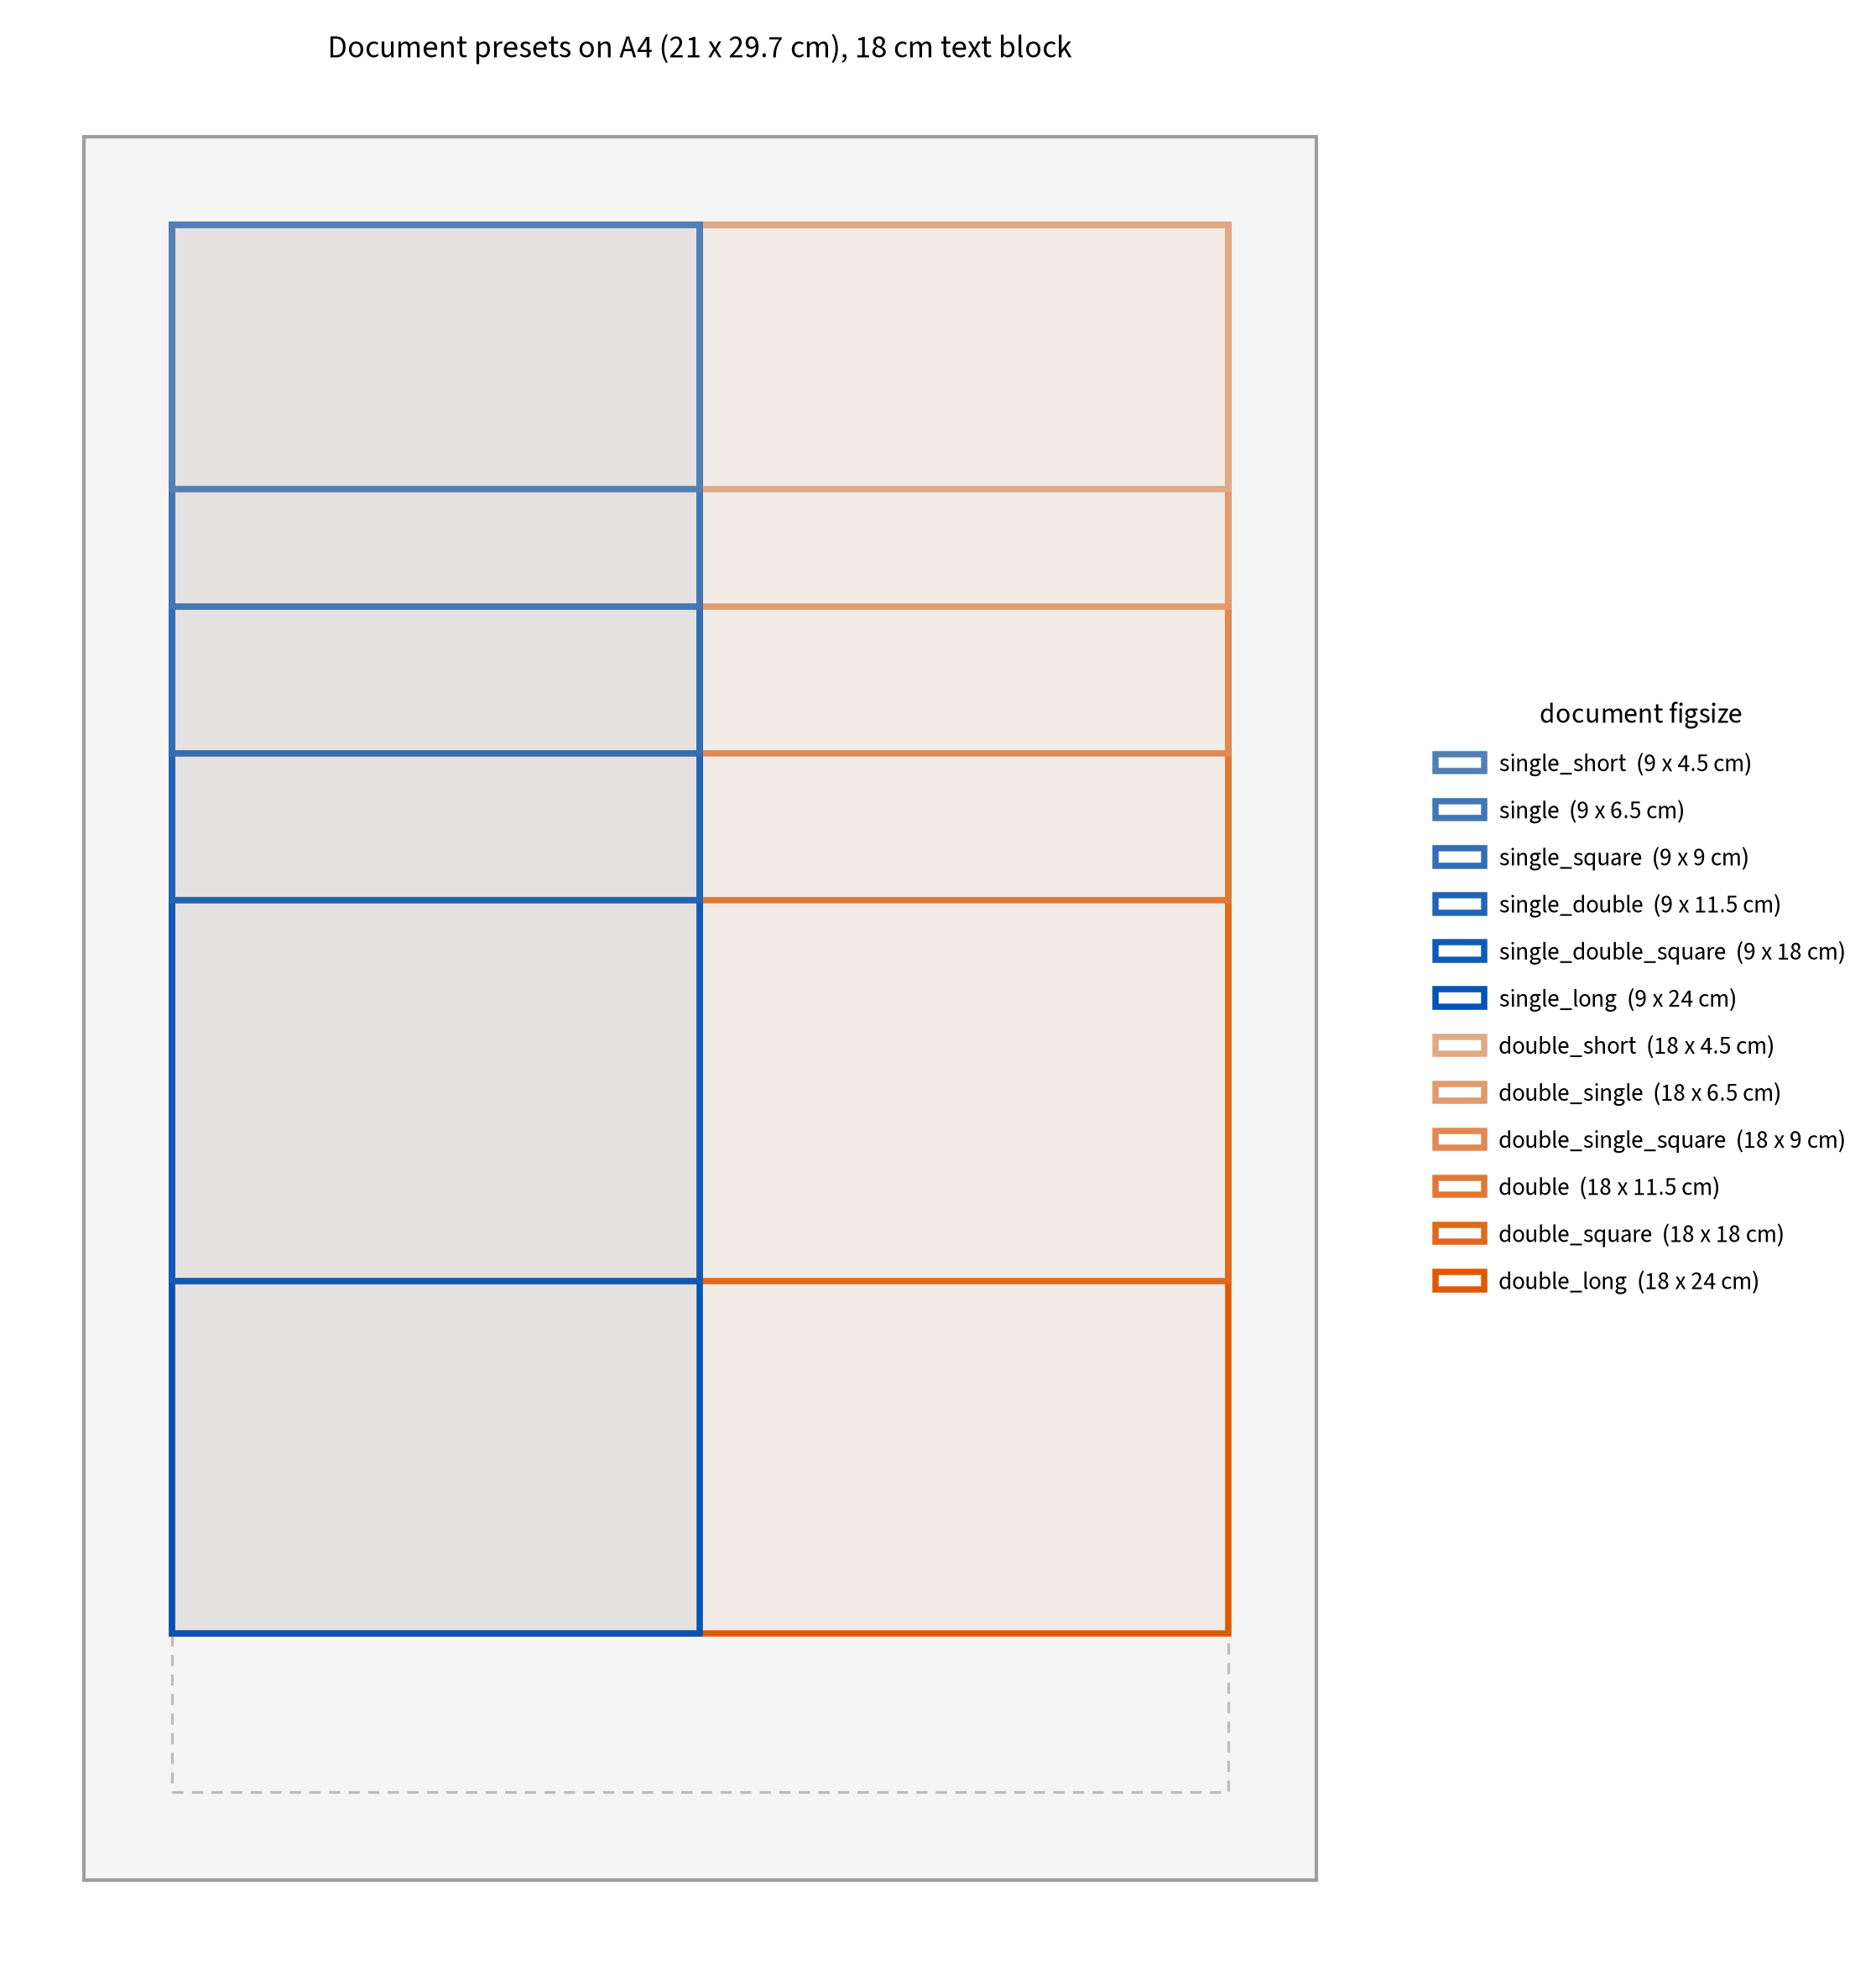

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 9.6))
draw_medium(
    ax, A4,
    anchor=(A4_MARGIN, A4[1] - A4_MARGIN),
    presets=DOC,
    text_area=(A4_MARGIN, A4_MARGIN, A4[0] - 2 * A4_MARGIN, A4[1] - 2 * A4_MARGIN),
    band_groups=[(SINGLE, BAND_SINGLE), (DOUBLE, BAND_DOUBLE)],
    title="Document presets on A4 (21 x 29.7 cm), 18 cm text block",
)
fig.legend(handles=legend_handles(DOC), loc="center left", bbox_to_anchor=(0.92, 0.5),
           fontsize=7, frameon=False, title="document figsize", title_fontsize=8)
save_figure(fig, DUMP, "figsizes_on_a4")
plt.show()

## Presentation presets on a 16:9 slide

The `slide_*` presets are sized to sit on a slide with a title bar and margins
around them (they deliberately do **not** fill the slide edge-to-edge).

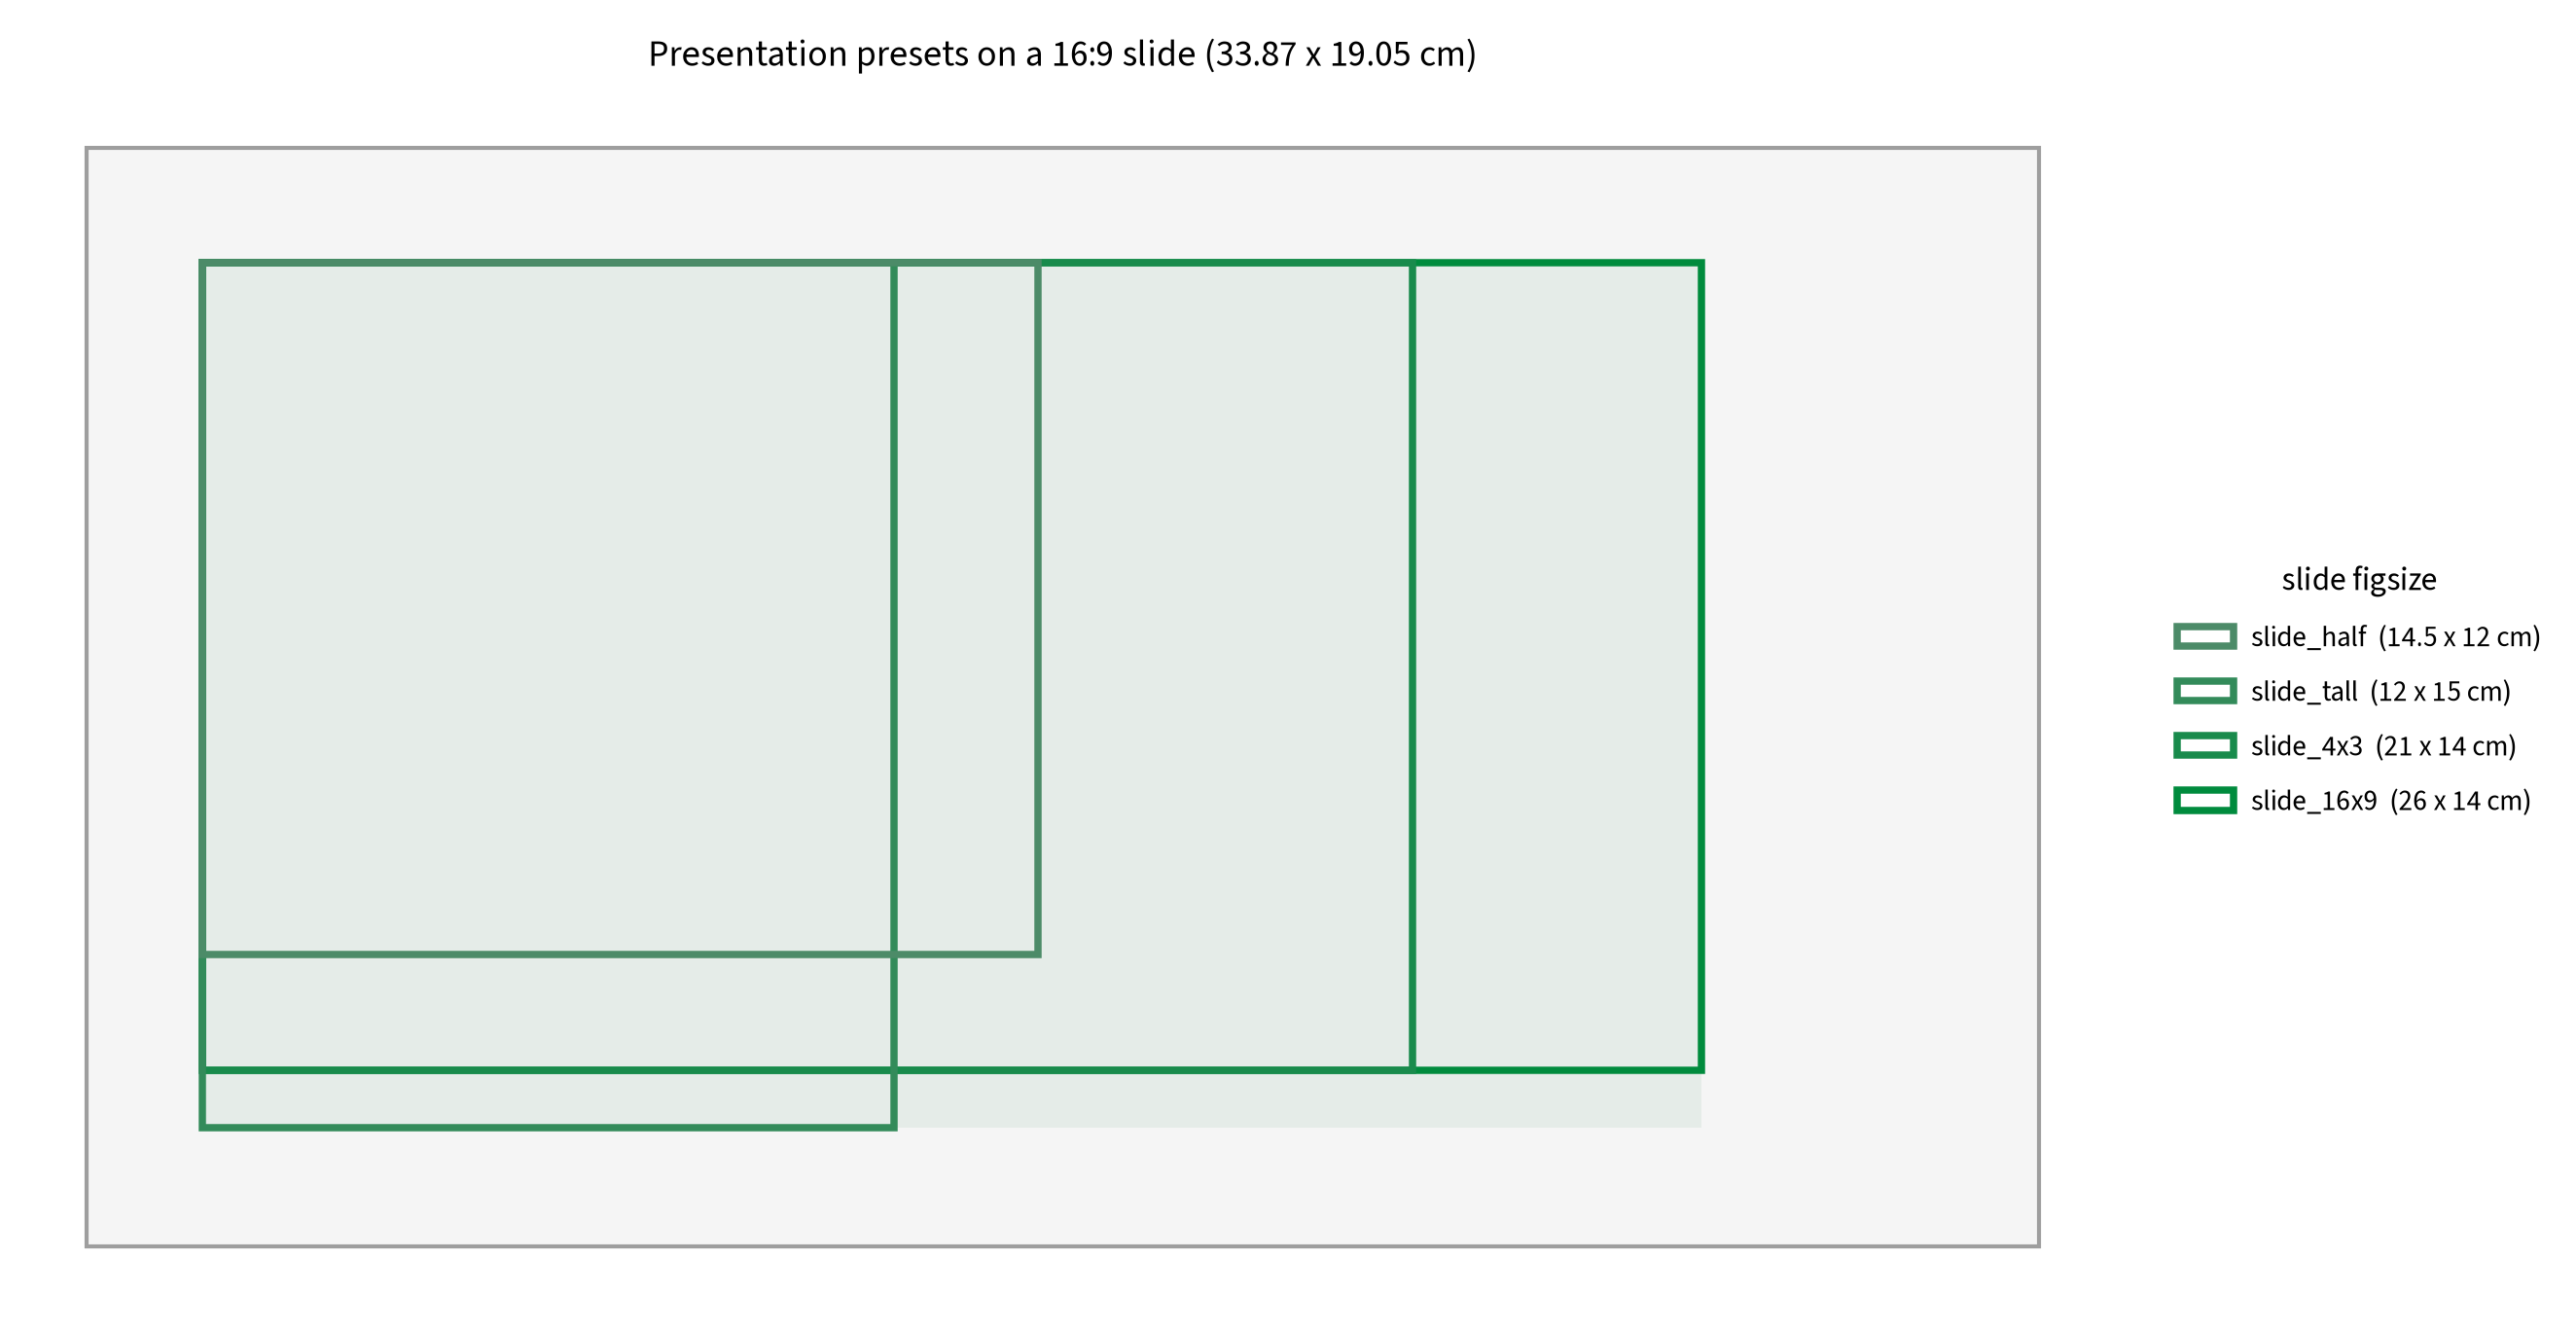

In [5]:
fig, ax = plt.subplots(figsize=(9.2, 5.4))
draw_medium(
    ax, SLIDE_169,
    anchor=(2.0, SLIDE_169[1] - 2.0),
    presets=SLIDE_PRESETS,
    band_groups=[(SLIDE_PRESETS, BAND_SLIDE)],
    title="Presentation presets on a 16:9 slide (33.87 x 19.05 cm)",
)
fig.legend(handles=legend_handles(SLIDE_PRESETS), loc="center left", bbox_to_anchor=(0.92, 0.5),
           fontsize=7, frameon=False, title="slide figsize", title_fontsize=8)
save_figure(fig, DUMP, "figsizes_on_slide_16x9")
plt.show()

## Side-by-side, same scale

Document presets on A4 (left) and slide presets on a 16:9 slide (right), drawn at
the **same** cm scale.

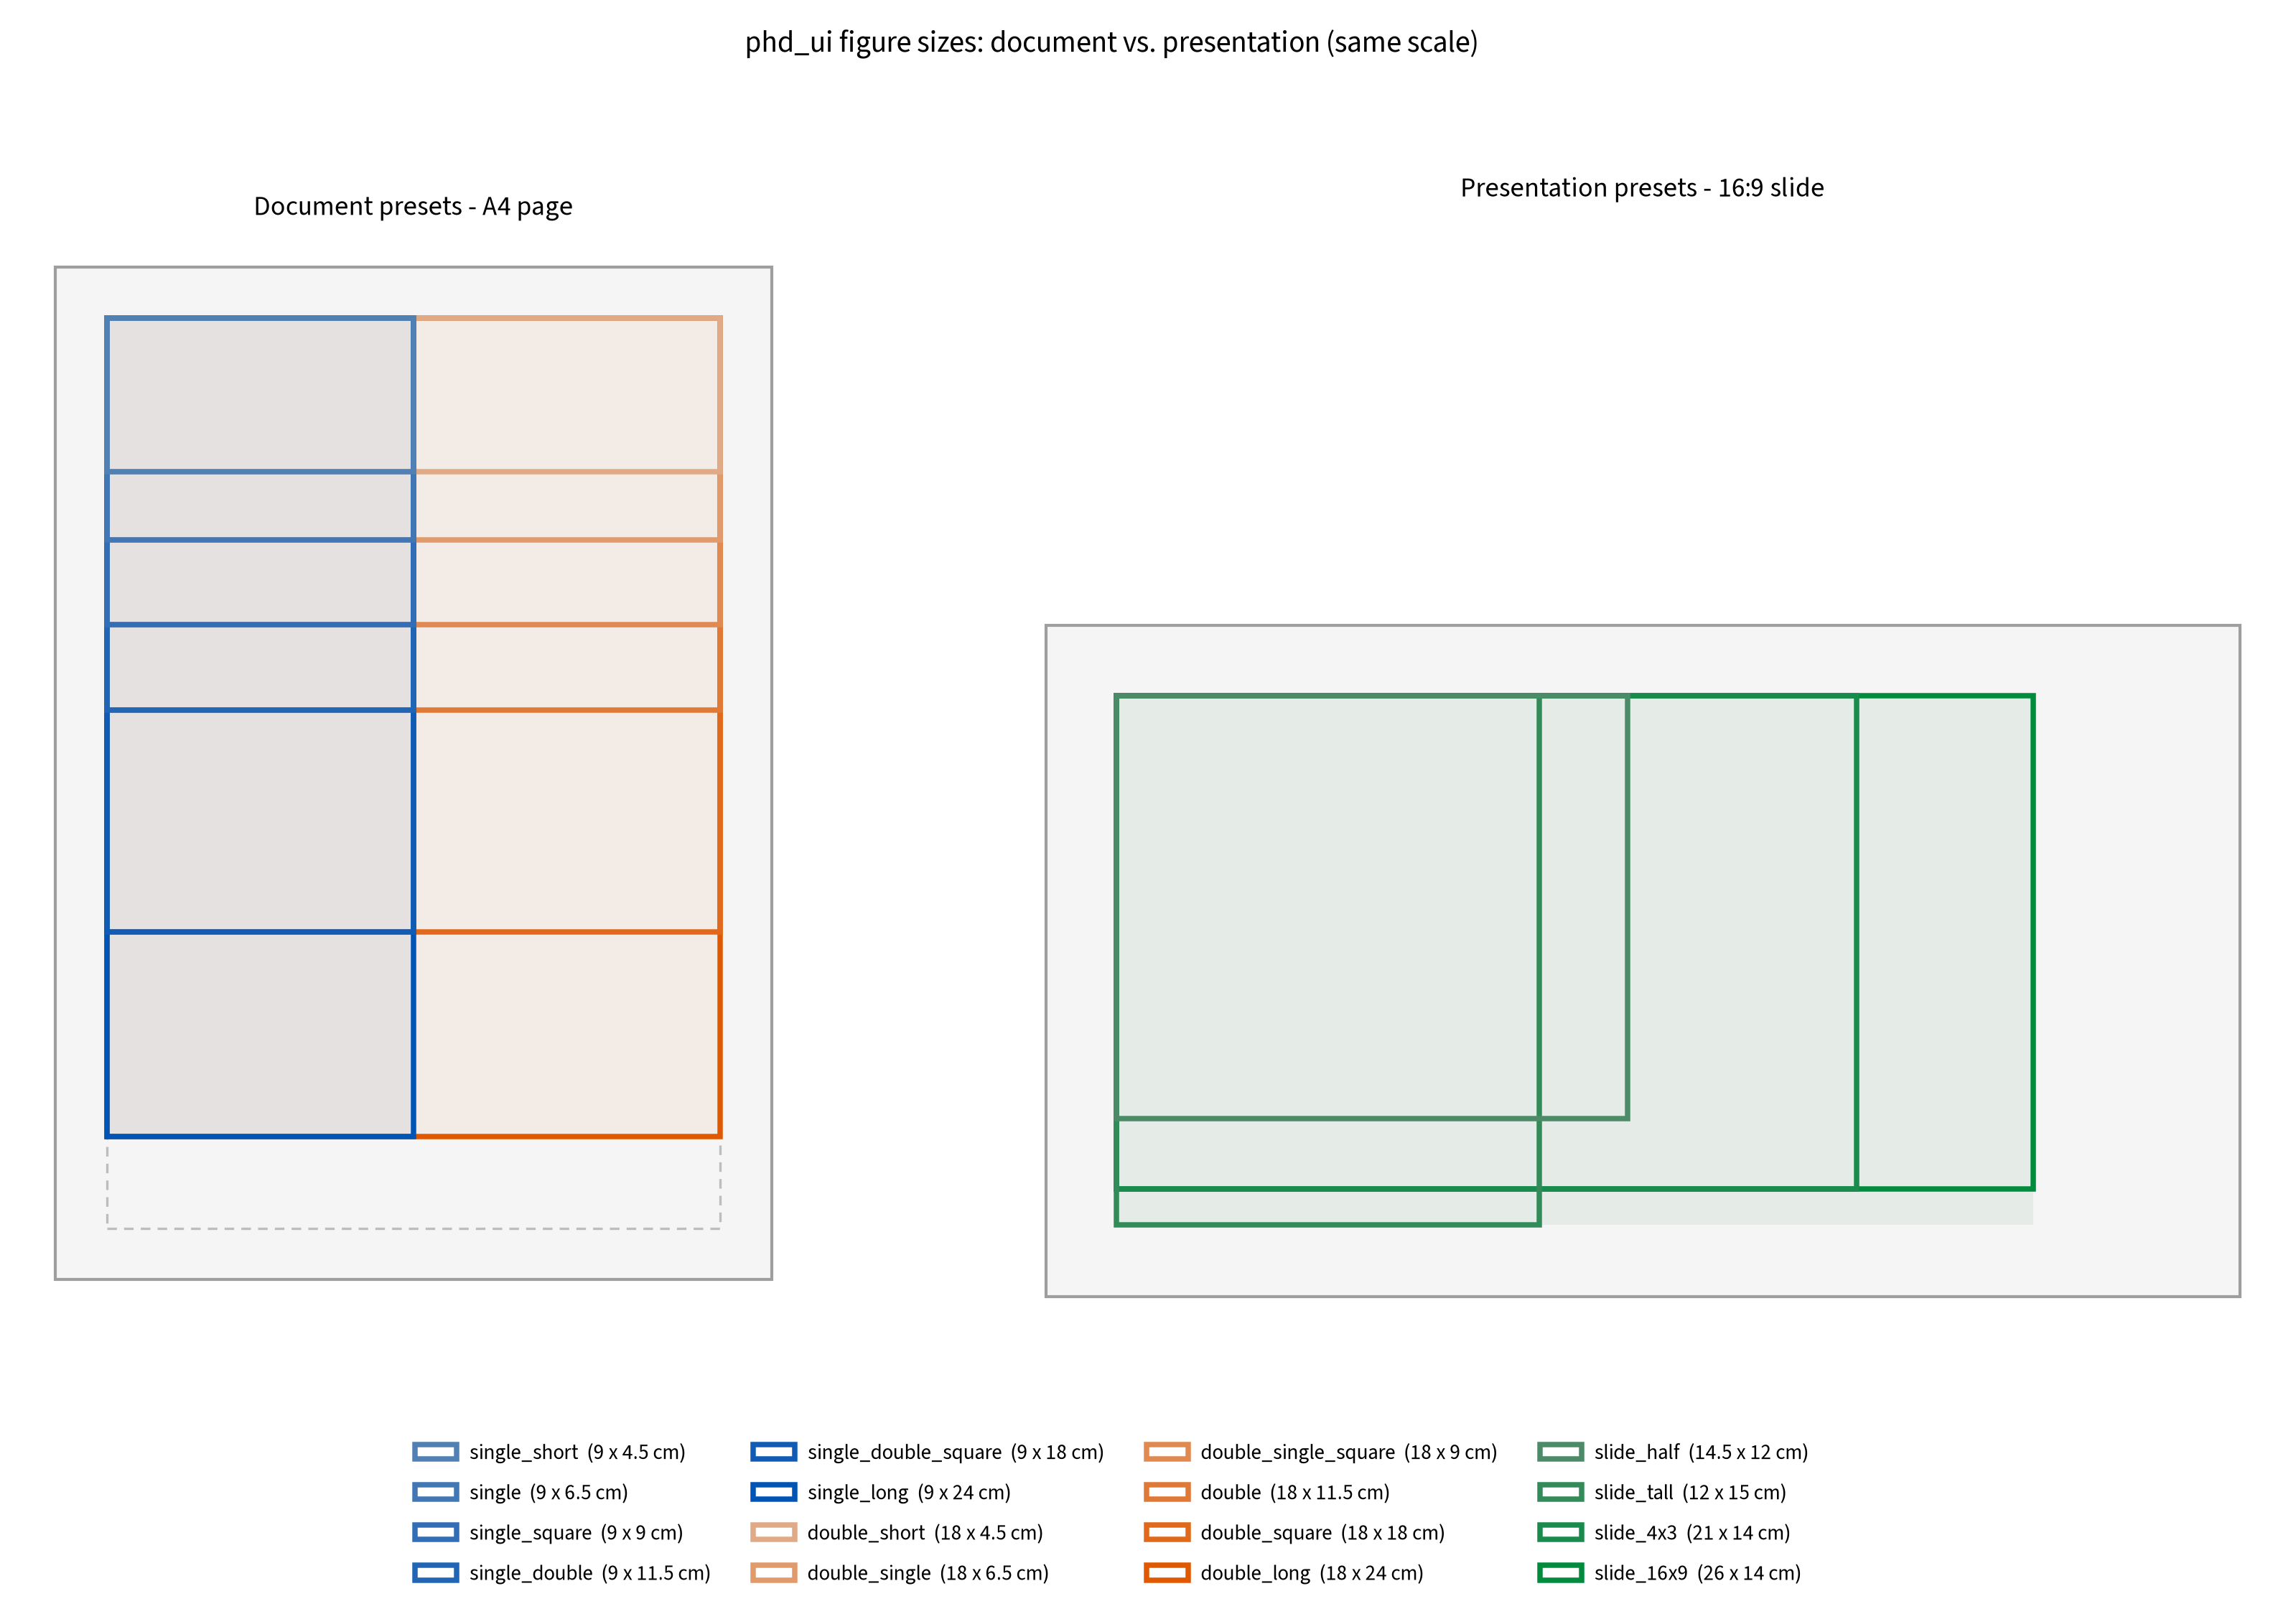

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 7.2),
                               gridspec_kw={"width_ratios": [A4[0], SLIDE_169[0]]})
draw_medium(
    axL, A4, anchor=(A4_MARGIN, A4[1] - A4_MARGIN), presets=DOC,
    text_area=(A4_MARGIN, A4_MARGIN, A4[0] - 2 * A4_MARGIN, A4[1] - 2 * A4_MARGIN),
    band_groups=[(SINGLE, BAND_SINGLE), (DOUBLE, BAND_DOUBLE)],
    title="Document presets - A4 page",
)
draw_medium(
    axR, SLIDE_169, anchor=(2.0, SLIDE_169[1] - 2.0), presets=SLIDE_PRESETS,
    band_groups=[(SLIDE_PRESETS, BAND_SLIDE)],
    title="Presentation presets - 16:9 slide",
)
ymin = min(axL.get_ylim()[0], axR.get_ylim()[0])
ymax = max(axL.get_ylim()[1], axR.get_ylim()[1])
axL.set_ylim(ymin, ymax)
axR.set_ylim(ymin, ymax)
fig.legend(handles=legend_handles(DOC + SLIDE_PRESETS), loc="lower center",
           bbox_to_anchor=(0.5, -0.04), ncol=4, fontsize=7, frameon=False)
fig.suptitle("phd_ui figure sizes: document vs. presentation (same scale)", fontsize=10)
save_figure(fig, DUMP, "figsizes_comparison")
plt.show()

## In context: a multi-page report & two slide decks

The same presets, dropped into **real deliverables**:

* a full-bleed multi-page **PDF** report (`mock_report.pdf`) exercising every
  *document* preset in a paper-like layout, and
* two **PowerPoint** files — `mock_slides_16x9.pptx` and `mock_slides_4x3.pptx` —
  whose figures are inserted at **true cm size**, so the decks themselves show how
  each `slide_*` preset lands.

Text is faked with grey bars; each figure slot carries a mini schematic chart.

In [7]:
rng = np.random.default_rng(7)

def fake_text(ax, x, ytop, w, n, *, line_h=0.5, color="#C9C9C9", lw=2.4, last_frac=0.55):
    # n grey bars simulating a paragraph, top-down from ytop.
    y = ytop
    for i in range(n):
        frac = last_frac if i == n - 1 else rng.uniform(0.85, 1.0)
        ax.plot([x, x + w * frac], [y, y], color=color, lw=lw,
                solid_capstyle="round", zorder=2)
        y -= line_h
    return y

def fake_plot(ax, x, y, w, h, color, *, pad=0.6):
    # a tiny schematic chart inside (x, y, w, h): L-axes + a curve.
    x0, y0, x1, y1 = x + pad, y + pad, x + w - pad, y + h - pad
    ax.plot([x0, x0, x1], [y1, y0, y0], color="#8A8A8A", lw=1.0, zorder=4)
    xs = np.linspace(x0, x1, 60)
    ys = y0 + (h - 2 * pad) * (0.45 + 0.35 * np.sin(np.linspace(0, 3.2, 60))
                               * np.linspace(0.4, 1.0, 60))
    ax.plot(xs, ys, color=color, lw=1.6, zorder=4)

def figure_slot(ax, x, y, w, h, name, color, *, n=1, caption=True):
    ax.add_patch(Rectangle((x, y), w, h, facecolor="white", edgecolor=color, lw=1.6, zorder=3))
    ax.add_patch(Rectangle((x, y), w, h, facecolor=color, edgecolor="none", alpha=0.05, zorder=3))
    fake_plot(ax, x, y, w, h, color)
    if caption:
        pw, ph = FIGSIZES_CM[name]
        ax.text(x, y - 0.35, f"Figure {n} - {name} ({pw:g} x {ph:g} cm)",
                ha="left", va="top", fontsize=6.5, style="italic", color="#555555", zorder=4)

### Multi-page PDF report

A full-bleed A4 document (the title is part of the header design, no page frame).
Every document preset appears in context across the pages.

In [8]:
from matplotlib.backends.backend_pdf import PdfPages

PW, PH = A4
M = A4_MARGIN
TX, TW = M, PW - 2 * M
DARK, ACCENT = "#2F3B52", "#E07B39"

def new_page():
    fig = plt.figure(figsize=(cm_to_inches(PW), cm_to_inches(PH)))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, PW); ax.set_ylim(0, PH)
    ax.set_aspect("equal"); ax.axis("off")
    return fig, ax

def cover_header(ax, title, subtitle):
    ax.add_patch(Rectangle((0, PH - 4.4), PW, 4.4, facecolor=DARK, edgecolor="none", zorder=1))
    ax.add_patch(Rectangle((0, PH - 4.55), PW, 0.15, facecolor=ACCENT, edgecolor="none", zorder=2))
    ax.text(M, PH - 2.1, title, color="white", fontsize=21, va="center", zorder=3)
    ax.text(M, PH - 3.3, subtitle, color="#C9CEDA", fontsize=10.5, va="center", zorder=3)
    return PH - 4.4 - 0.9

def running_header(ax, section):
    ax.text(M, PH - M + 0.25, section, color=DARK, fontsize=8, va="bottom", ha="left", zorder=3)
    ax.text(PW - M, PH - M + 0.25, "phd_ui figure-size guide", color="#9AA0AC",
            fontsize=8, va="bottom", ha="right", zorder=3)
    ax.plot([M, PW - M], [PH - M, PH - M], color=DARK, lw=1.0, zorder=3)
    return PH - M - 0.8

def footer(ax, page_no):
    ax.plot([M, PW - M], [M - 0.35, M - 0.35], color="#DADADA", lw=0.8, zorder=3)
    ax.text(PW - M, M - 0.7, str(page_no), color="#9AA0AC", fontsize=8, ha="right", va="top", zorder=3)

def two_up(ax, y, left, right, start_n):
    # two 9-cm-wide figures side by side, top-aligned at y; returns new cursor.
    wl, hl = FIGSIZES_CM[left]
    wr, hr = FIGSIZES_CM[right]
    figure_slot(ax, TX, y - hl, wl, hl, left, COLOR[left], n=start_n)
    figure_slot(ax, TX + wl, y - hr, wr, hr, right, COLOR[right], n=start_n + 1)
    return y - max(hl, hr) - 1.2

def full_row(ax, y, name, n):
    w, h = FIGSIZES_CM[name]
    figure_slot(ax, TX, y - h, w, h, name, COLOR[name], n=n)
    return y - h - 1.2

pdf_path = DUMP / "mock_report.pdf"
with PdfPages(pdf_path) as pdf:
    # page 1: cover + intro + full-width double
    fig, ax = new_page()
    y = cover_header(ax, "Reactor Performance Report", "CO2-to-methanol - a figure-size catalogue")
    y = fake_text(ax, TX, y, TW, 3) - 0.5
    y = full_row(ax, y, "double", 1)
    fake_text(ax, TX, y, TW, 2)
    footer(ax, 1); pdf.savefig(fig, facecolor="white"); plt.close(fig)

    # page 2: short + single-height presets (four figures on one page)
    fig, ax = new_page()
    y = running_header(ax, "2   Results")
    y = fake_text(ax, TX, y, TW, 1) - 0.4
    y = two_up(ax, y, "single_short", "single", 2)
    y = fake_text(ax, TX, y, TW, 1) - 0.4
    y = full_row(ax, y, "double_single", 4)
    y = full_row(ax, y, "double_short", 5)
    footer(ax, 2); pdf.savefig(fig, facecolor="white"); plt.close(fig)

    # page 3: square / double-height presets (three figures)
    fig, ax = new_page()
    y = running_header(ax, "3   Methods")
    y = fake_text(ax, TX, y, TW, 1) - 0.4
    y = two_up(ax, y, "single_square", "single_double", 6)
    y = fake_text(ax, TX, y, TW, 1) - 0.4
    y = full_row(ax, y, "double_single_square", 8)
    footer(ax, 3); pdf.savefig(fig, facecolor="white"); plt.close(fig)

    # page 4: full-width, tall
    fig, ax = new_page()
    y = running_header(ax, "4   Discussion")
    y = fake_text(ax, TX, y, TW, 1) - 0.4
    full_row(ax, y, "double_square", 9)
    footer(ax, 4); pdf.savefig(fig, facecolor="white"); plt.close(fig)

    # page 5: the tall single-width pair, side by side
    fig, ax = new_page()
    y = running_header(ax, "5   Appendix A")
    two_up(ax, y, "single_double_square", "single_long", 10)
    footer(ax, 5); pdf.savefig(fig, facecolor="white"); plt.close(fig)

    # page 6: the full-page portrait figure
    fig, ax = new_page()
    y = running_header(ax, "6   Appendix B")
    full_row(ax, y, "double_long", 12)
    footer(ax, 6); pdf.savefig(fig, facecolor="white"); plt.close(fig)

# Remove superseded single-page / single-deck exports (best-effort: a file open
# in PowerPoint or locked by OneDrive sync is skipped rather than failing the run).
def _try_unlink(p):
    try:
        if p.exists():
            p.unlink()
    except PermissionError:
        print(f"  (skipped locked file: {p.name})")

for stale in ["mock_report_a4", "mock_slide_16x9"]:
    for ext in ("pdf", "png", "svg"):
        _try_unlink(DUMP / f"{stale}.{ext}")
_try_unlink(DUMP / "mock_slides.pptx")

print("wrote", pdf_path)

wrote C:\Users\jsommer1\OneDrive\02_Projects\[UniZeug]\2024_PhD\01_Project\[figure_dump]\phd_ui\mock_report.pdf


### PowerPoint decks (`.pptx`)

Two real presentations — 16:9 and 4:3. Each figure is rendered to an image and
inserted at its **true cm size**, so opening a deck shows the real scale of each
`slide_*` preset. Recall both decks are the same height (19.05 cm); the 4:3 deck
is just narrower, so `slide_4x3` is the size that fits it comfortably.

In [9]:
import tempfile
from pptx import Presentation
from pptx.util import Inches, Cm, Pt
from pptx.dml.color import RGBColor
from pptx.enum.shapes import MSO_SHAPE

RGB_DARK = RGBColor(0x2F, 0x3B, 0x52)
RGB_ACCENT = RGBColor(0xE0, 0x7B, 0x39)
RGB_GREY = RGBColor(0x55, 0x55, 0x55)
RGB_WHITE = RGBColor(0xFF, 0xFF, 0xFF)

tmpdir = Path(tempfile.mkdtemp())

def render_chart(name):
    # standalone mini-chart at the preset's true size -> transparent PNG.
    w, h = FIGSIZES_CM[name]
    color = COLOR[name]
    f = plt.figure(figsize=(cm_to_inches(w), cm_to_inches(h)))
    a = f.add_axes([0, 0, 1, 1])
    a.set_xlim(0, w); a.set_ylim(0, h); a.set_aspect("equal"); a.axis("off")
    a.add_patch(Rectangle((0.08, 0.08), w - 0.16, h - 0.16, facecolor="white",
                          edgecolor=color, lw=1.6))
    fake_plot(a, 0, 0, w, h, color, pad=min(w, h) * 0.14)
    out = tmpdir / f"{name}.png"
    f.savefig(out, dpi=200, transparent=True)
    plt.close(f)
    return out

def title_band(prs, slide, title):
    band = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, 0, 0, prs.slide_width, Cm(3.0))
    band.fill.solid(); band.fill.fore_color.rgb = RGB_DARK; band.line.fill.background()
    band.shadow.inherit = False
    acc = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, 0, Cm(3.0), prs.slide_width, Cm(0.18))
    acc.fill.solid(); acc.fill.fore_color.rgb = RGB_ACCENT; acc.line.fill.background()
    acc.shadow.inherit = False
    tf = band.text_frame; tf.margin_left = Cm(1.2)
    r = tf.paragraphs[0].add_run(); r.text = title
    r.font.size = Pt(28); r.font.bold = True; r.font.color.rgb = RGB_WHITE

def bullets(slide, lines, left_cm, top_cm, width_cm, height_cm):
    tb = slide.shapes.add_textbox(Cm(left_cm), Cm(top_cm), Cm(width_cm), Cm(height_cm))
    tf = tb.text_frame; tf.word_wrap = True
    for i, line in enumerate(lines):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        r = p.add_run(); r.text = "\u2022  " + line
        r.font.size = Pt(15); r.font.color.rgb = RGB_DARK
        p.space_after = Pt(8)

def place_figure(slide, name, left_cm, top_cm, *, caption=True):
    w, h = FIGSIZES_CM[name]
    slide.shapes.add_picture(str(render_chart(name)), Cm(left_cm), Cm(top_cm),
                             width=Cm(w), height=Cm(h))
    if caption:
        cap = slide.shapes.add_textbox(Cm(left_cm), Cm(top_cm + h + 0.05), Cm(w), Cm(0.9))
        r = cap.text_frame.paragraphs[0].add_run()
        r.text = f"{name}  ({w:g} x {h:g} cm)"
        r.font.size = Pt(11); r.font.italic = True; r.font.color.rgb = RGB_GREY

def title_slide(prs, headline, sub):
    s = prs.slides.add_slide(prs.slide_layouts[6])
    bg = s.shapes.add_shape(MSO_SHAPE.RECTANGLE, 0, 0, prs.slide_width, prs.slide_height)
    bg.fill.solid(); bg.fill.fore_color.rgb = RGB_DARK; bg.line.fill.background(); bg.shadow.inherit = False
    acc = s.shapes.add_shape(MSO_SHAPE.RECTANGLE, Cm(2.0), Cm(6.2), Cm(6), Cm(0.15))
    acc.fill.solid(); acc.fill.fore_color.rgb = RGB_ACCENT; acc.line.fill.background(); acc.shadow.inherit = False
    tb = s.shapes.add_textbox(Cm(2.0), Cm(6.5), prs.slide_width - Cm(4), Cm(5))
    tf = tb.text_frame; tf.word_wrap = True
    r = tf.paragraphs[0].add_run(); r.text = headline
    r.font.size = Pt(36); r.font.bold = True; r.font.color.rgb = RGB_WHITE
    p2 = tf.add_paragraph(); r2 = p2.add_run(); r2.text = sub
    r2.font.size = Pt(15); r2.font.color.rgb = RGBColor(0xC9, 0xCE, 0xDA)
    return s

def new_prs(w_in, h_in):
    prs = Presentation()
    prs.slide_width = Inches(w_in)
    prs.slide_height = Inches(h_in)
    return prs

# ---------- 16:9 deck ----------
prs = new_prs(13.333, 7.5)
SW = 33.867
title_slide(prs, "phd_ui slide figures", "presentation presets at true size on a 16:9 slide")

s = prs.slides.add_slide(prs.slide_layouts[6])
title_band(prs, s, "slide_16x9 - a slide-filling hero")
place_figure(s, "slide_16x9", (SW - 26) / 2, 3.6)

s = prs.slides.add_slide(prs.slide_layouts[6])
title_band(prs, s, "slide_half - two figures side by side")
place_figure(s, "slide_half", (SW - (2 * 14.5 + 1.5)) / 2, 4.0)
place_figure(s, "slide_half", (SW - (2 * 14.5 + 1.5)) / 2 + 14.5 + 1.5, 4.0)

s = prs.slides.add_slide(prs.slide_layouts[6])
title_band(prs, s, "slide_tall - a portrait figure beside bullets")
bullets(s, ["Conversion rises with temperature", "Selectivity peaks near 250 C",
            "Model matches the measured trend"], 1.5, 4.0, 17, 12)
place_figure(s, "slide_tall", SW - 12 - 1.5, 3.4, caption=False)

pptx16 = DUMP / "mock_slides_16x9.pptx"
prs.save(str(pptx16))

# ---------- 4:3 deck ----------
prs = new_prs(10.0, 7.5)
SW = 25.4
title_slide(prs, "phd_ui slide figures", "presentation presets at true size on a 4:3 slide")

s = prs.slides.add_slide(prs.slide_layouts[6])
title_band(prs, s, "slide_4x3 - a slide-filling hero")
place_figure(s, "slide_4x3", (SW - 21) / 2, 3.6)

s = prs.slides.add_slide(prs.slide_layouts[6])
title_band(prs, s, "slide_tall - a portrait figure beside bullets")
bullets(s, ["Conversion rises with temperature", "Selectivity peaks near 250 C",
            "Model matches the measured trend"], 1.2, 4.0, 10.5, 12)
place_figure(s, "slide_tall", SW - 12 - 1.2, 3.4, caption=False)

pptx43 = DUMP / "mock_slides_4x3.pptx"
prs.save(str(pptx43))

# Keep a copy of the three mock deliverables in the repo's docs/ folder.
import shutil
for _f in [pdf_path, pptx16, pptx43]:
    shutil.copy2(_f, DOCS / _f.name)

print("wrote", pptx16)
print("wrote", pptx43)
print("copied mocks to", DOCS)

wrote C:\Users\jsommer1\OneDrive\02_Projects\[UniZeug]\2024_PhD\01_Project\[figure_dump]\phd_ui\mock_slides_16x9.pptx
wrote C:\Users\jsommer1\OneDrive\02_Projects\[UniZeug]\2024_PhD\01_Project\[figure_dump]\phd_ui\mock_slides_4x3.pptx
copied mocks to C:\Users\jsommer1\CODE\PhD_ui\docs


## When to use which preset

**Document presets** (for papers / the thesis; 9 or 18 cm wide):

The document presets form a full **height x width matrix**: every height exists at
both the single (9 cm) and double (18 cm) width, and the name of the narrow one
mirrors the wide one at the same height.

| Height | single (9 cm wide) | double (18 cm wide) |
|---|---|---|
| 4.5 | `single_short` | `double_short` |
| 6.5 | `single` (default) | `double_single` |
| 9 | `single_square` | `double_single_square` |
| 11.5 | `single_double` | `double` |
| 18 | `single_double_square` | `double_square` |
| 24 | `single_long` | `double_long` |

| Preset | Size (cm) | Use it for |
|---|---|---|
| `single_short` | 9 x 4.5 | Half-width strip: a small inset, mini time trace / spectrum. |
| `single` | 9 x 6.5 | **Default.** One-column / half-width single-panel figure. |
| `single_square` | 9 x 9 | Square half-width axes: parity / correlation plots. |
| `single_double` | 9 x 11.5 | Tall half-width: a vertical profile or tall bar chart. |
| `single_double_square` | 9 x 18 | Very tall half-width: a stacked-spectra column. |
| `single_long` | 9 x 24 | Full-height half-width column: a long pathway / timeline. |
| `double_short` | 18 x 4.5 | Full-width strip: time series / TOS traces, spectra. |
| `double_single` | 18 x 6.5 | Full width at single height: a row of 2-3 panels (a)(b)(c). |
| `double_single_square` | 18 x 9 | Full width, moderate height: wide 1x3 panels, a map. |
| `double` | 18 x 11.5 | Full width; 2x2 grids or one busy panel. |
| `double_square` | 18 x 18 | Full width, tall: 3x3 grids, heatmaps, matrices. |
| `double_long` | 18 x 24 | Whole-page portrait figure (was `fullpage`). Documents only. |

**Presentation presets** (for slides; both aspect ratios are 19.05 cm tall):

| Preset | Size (cm) | Use it for |
|---|---|---|
| `slide_16x9` | 26 x 14 | Hero figure filling a 16:9 slide, with title + margins. |
| `slide_4x3` | 21 x 14 | Hero figure for a 4:3 slide (narrower usable width). |
| `slide_half` | 14.5 x 12 | Two figures side by side on a 16:9 slide. |
| `slide_tall` | 12 x 15 | Portrait figure beside a bullet list. |
